In [2]:
import cv2
from pupil_apriltags import Detector
import matplotlib.pyplot as plt

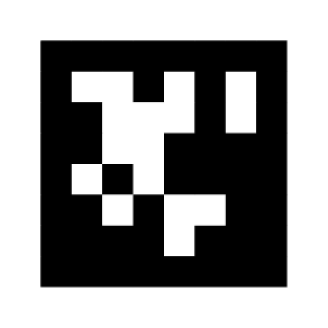

In [3]:
img_path = './images/tag36_11.png'
image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(4,4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [4]:

cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)


2026-01-20 12:40:56.030 python[37438:65992020] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


True

In [10]:
cap.release()

In [11]:
ret, frame = cap.read()
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
image = gray
tag_size = 0.1  # meters
fx, fy, cx, cy = 600, 600, 320, 240  # 用你真实相机参数替换

error: OpenCV(4.11.0) /Users/runner/miniforge3/conda-bld/libopencv_1750205176060/work/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [9]:
detector = Detector(
    families="tag36h11",   # 你用的tag36h11就是它
    nthreads=4,
    quad_decimate=2.0,     # >1 会更快但更粗糙；2.0常用于提速
    quad_sigma=0.0,
    refine_edges=1,
)

detections = detector.detect(image)
image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
print("num tags:", len(detections))
for d in detections:
    print("id:", d.tag_id, "center:", d.center)

    # d.corners: (4,2) float
    corners = d.corners.astype(int)
    for i in range(4):
        cv2.line(image, tuple(corners[i]), tuple(corners[(i+1)%4]), (0, 255, 0), 3)

plt.imshow(image, cmap="gray"); plt.axis("off"); plt.show()

AssertionError: 

In [12]:
import requests

def probe_neon_device(ip: str, port: int = 8080, timeout=2.0):
    url = f"http://{ip}:{port}/api"
    try:
        r = requests.get(url, timeout=timeout)
        print(f"[+] {ip}:{port} reachable, status={r.status_code}")
        print(r.text[:200])
        return True
    except requests.RequestException as e:
        print(f"[-] {ip}:{port} not reachable: {e}")
        return False

In [17]:
probe_neon_device("192.168.0.102")


[+] 192.168.0.102:8080 reachable, status=404
Error 404, file not found.


True